# 2. Imports & Setup

In [1]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"]) #ensure pip is installed

0

In [2]:
!"{sys.executable}" -m pip install meteostat 
#install meteostat package


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from datetime import datetime
import matplotlib.pyplot as plt

import pandas as pd

In [4]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 3. Load Data from website

In [5]:
import meteostat as ms

In [6]:
# Get nearby weather stations
POINT = ms.Point(44.182205, -84.506836, 300)
stations = ms.stations.nearby(POINT, limit=8)

# Print DataFrame
print(stations)

                                            name country region  latitude  \
id                                                                          
72638                   Roscommon County Airport      US     MI   44.3500   
KY310  West Branch / Twin Pines Mobile Home Park      US     MI   44.2448   

       longitude  elevation         timezone  distance  
id                                                      
72638   -84.6667        351  America/Detroit   22586.7  
KY310   -84.1798        269  America/Detroit   26977.6  


### Load weather data 

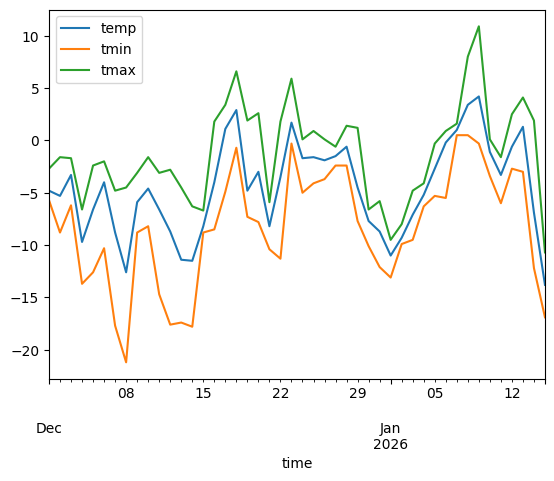

In [7]:
# Set time period
START = datetime(2025, 12, 1)
END = datetime(2026, 1, 15)


# Get daily data
data = ms.daily(stations, START, END)
df = ms.interpolate(data, POINT).fetch()

df.plot(y=[ms.Parameter.TEMP, ms.Parameter.TMIN, ms.Parameter.TMAX])
plt.show()

In [8]:
df.describe()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,cldc
count,46.0,46.0,46.0,46.0,46.0,41.0,46.0,1.0,44.0,46.0
mean,-4.55,-8.28913,-1.186957,82.478261,2.078261,18.219512,13.03913,41.0,1012.402273,6.608696
std,4.436803,5.475003,4.53743,8.043601,3.195825,7.226729,5.168343,<NA>,7.654775,1.021508
min,-13.8,-21.2,-10.7,64.0,0.0,0.0,3.9,41.0,997.9,4.0
25%,-8.075,-11.9,-4.5,77.25,0.0,13.0,9.425,41.0,1008.325,6.0
50%,-4.55,-8.0,-1.6,82.0,0.5,20.0,12.35,41.0,1011.05,7.0
75%,-1.525,-4.3,1.75,87.75,2.4,23.0,15.7,41.0,1016.875,7.0
max,4.2,0.5,10.9,99.0,11.7,28.0,27.9,41.0,1026.1,8.0


### Sanity Check

In [9]:
# Plot function

def Plot(df, category, Title):
    #full_index = pd.date_range(start=start, end=end)
    df = df.copy()
    df.plot(y=[category])

    plt.xlabel('Date')
    plt.ylabel(Title)
    plt.title(f"{Title} for Michigan (2025-2026)")
    plt.show()

In [10]:
df.isna().sum()

temp     0
tmin     0
tmax     0
rhum     0
prcp     0
snwd     5
wspd     0
wpgt    45
pres     2
cldc     0
dtype: int64

#### Temperature

##### Avg

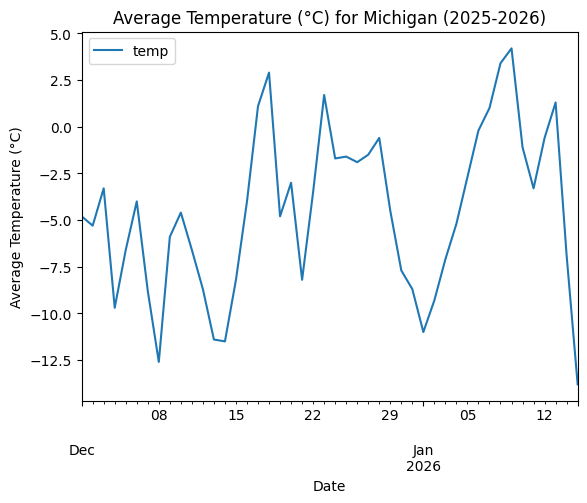

In [11]:
Plot(df, 'temp', 'Average Temperature (°C)')

## Plot Predictions vs. Actual Values

In [12]:
# renaming temp to tavg for concat
data = df['temp'].rename('tavg')
data

time
2025-12-01    -4.8
2025-12-02    -5.3
2025-12-03    -3.3
2025-12-04    -9.7
2025-12-05    -6.6
2025-12-06    -4.0
2025-12-07    -8.8
2025-12-08   -12.6
2025-12-09    -5.9
2025-12-10    -4.6
2025-12-11    -6.6
2025-12-12    -8.7
2025-12-13   -11.4
2025-12-14   -11.5
2025-12-15    -8.2
2025-12-16    -4.0
2025-12-17     1.1
2025-12-18     2.9
2025-12-19    -4.8
2025-12-20    -3.0
2025-12-21    -8.2
2025-12-22    -3.5
2025-12-23     1.7
2025-12-24    -1.7
2025-12-25    -1.6
2025-12-26    -1.9
2025-12-27    -1.5
2025-12-28    -0.6
2025-12-29    -4.5
2025-12-30    -7.7
2025-12-31    -8.7
2026-01-01   -11.0
2026-01-02    -9.3
2026-01-03    -7.1
2026-01-04    -5.2
2026-01-05    -2.7
2026-01-06    -0.2
2026-01-07     1.0
2026-01-08     3.4
2026-01-09     4.2
2026-01-10    -1.1
2026-01-11    -3.3
2026-01-12    -0.6
2026-01-13     1.3
2026-01-14    -6.9
2026-01-15   -13.8
Name: tavg, dtype: Float64

In [18]:
data.describe()

count        46.0
mean        -4.55
std      4.436803
min         -13.8
25%        -8.075
50%         -4.55
75%        -1.525
max           4.2
Name: tavg, dtype: Float64

In [19]:
data.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 46 entries, 2025-12-01 to 2026-01-15
Series name: tavg
Non-Null Count  Dtype  
--------------  -----  
46 non-null     Float64
dtypes: Float64(1)
memory usage: 782.0 bytes


In [13]:
preprocessed_data = pd.read_csv(r'C:\Users\Celina Binder\Documents\github_respository\TIS3IL-WS25-Project\data\processed\processed_weather_data_michigan.csv', index_col='time')

In [33]:
df_old = preprocessed_data.reset_index(drop=False)
df_new = data.reset_index(drop=False)

df_old["time"] = pd.to_datetime(df_old["time"])
df_new["time"] = pd.to_datetime(df_new["time"])

df_all = (
    pd.concat([df_old, df_new], ignore_index=True)
      .sort_values("time")
      .drop_duplicates(subset="time", keep="last")
      .reset_index(drop=True)
)

In [34]:
df_all

,time,tavg,tmin,tmax,prcp,snow,wspd
0,1980-01-01,-0.85,-2.8,1.1,0.0,2.000000,13.561500
1,1980-01-02,-3.9,-7.2,-0.6,0.0,2.000000,13.933889
2,1980-01-03,-8.85,-13.3,-4.4,0.0,2.000000,13.908000
3,1980-01-04,-10.3,-16.7,-3.9,0.0,3.857143,14.128556
4,1980-01-05,-7.5,-12.8,-2.2,0.0,5.000000,15.247333
...,...,...,...,...,...,...,...
16809,2026-01-11,-3.3,NaN,NaN,NaN,NaN,NaN
16810,2026-01-12,-0.6,NaN,NaN,NaN,NaN,NaN
16811,2026-01-13,1.3,NaN,NaN,NaN,NaN,NaN
16812,2026-01-14,-6.9,NaN,NaN,NaN,NaN,NaN
